In [1]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator

# 1. Load the victim circuit (originally on qubits 0–9; we map it to 10–19)
victim = QuantumCircuit.from_qasm_file("ising_n10(victim).qasm")

# 2. Build attacker 1 (qubits 0–9) with repeated CNOTs to maximize cross-talk
attacker1 = QuantumCircuit(30)
for i in range(5):
    for j in range(9):
        attacker1.cx(j, j+1)
    for j in range(9, 0, -1):
        attacker1.cx(j, j-1)
print("Attacker1 circuit constructed successfully!")

# 3. Build attacker 2 (qubits 20–29) with repeated CNOTs as well
attacker2 = QuantumCircuit(30)
for i in range(5):
    for j in range(20, 29):
        attacker2.cx(j, j+1)
    for j in range(29, 20, -1):
        attacker2.cx(j, j-1)
print("Attacker2 circuit constructed successfully!")

# 4. Combine the three segments into a single 30-qubit circuit:
#    - Attacker1 on qubits 0–9
#    - Victim mapped to qubits 10–19
#    - Attacker2 on qubits 20–29
# Only the victim region is measured for analysis.
full = QuantumCircuit(30, 10)
full.compose(attacker1, qubits=range(30), inplace=True)
full.compose(victim, qubits=range(10, 20), clbits=range(10), inplace=True)
full.compose(attacker2, qubits=range(30), inplace=True)
full.measure(range(10, 20), range(10))
print("Full cross-talk attack circuit (sandwiched) constructed successfully!")

# 5. Run simulation
sim = AerSimulator()
job = sim.run(full)
result = job.result()
counts = result.get_counts()
print(counts)
print("Sandwiched attack simulation completed! Results ready for analysis.")

Attacker1 circuit constructed successfully!
Attacker2 circuit constructed successfully!
Full cross-talk attack circuit (sandwiched) constructed successfully!
{'0010111011': 1, '0100010100': 1, '1101110000': 1, '1001111010': 1, '1000010101': 1, '1100101101': 1, '1101100100': 1, '1000010000': 1, '1101000010': 1, '0000110001': 1, '1111000100': 1, '1000001011': 1, '1111111001': 2, '1110100101': 1, '1011001100': 1, '0100110101': 1, '0111100001': 1, '1110010000': 3, '0011101001': 1, '0011000010': 1, '1100011110': 1, '1100001100': 1, '1101001100': 1, '0110110000': 1, '1101111000': 1, '1100100010': 1, '0111110010': 1, '1111001110': 1, '0011110000': 1, '1000010011': 1, '0100111100': 1, '0011111001': 1, '0000001110': 1, '1010110011': 2, '0100010000': 2, '1100001001': 1, '1111111111': 1, '1111101000': 1, '1001010010': 3, '1111101101': 1, '1101010101': 1, '1110101110': 1, '0001111011': 1, '1000110101': 1, '1110111001': 1, '0011000011': 1, '1101110101': 1, '1100011111': 1, '1100001101': 2, '1011010

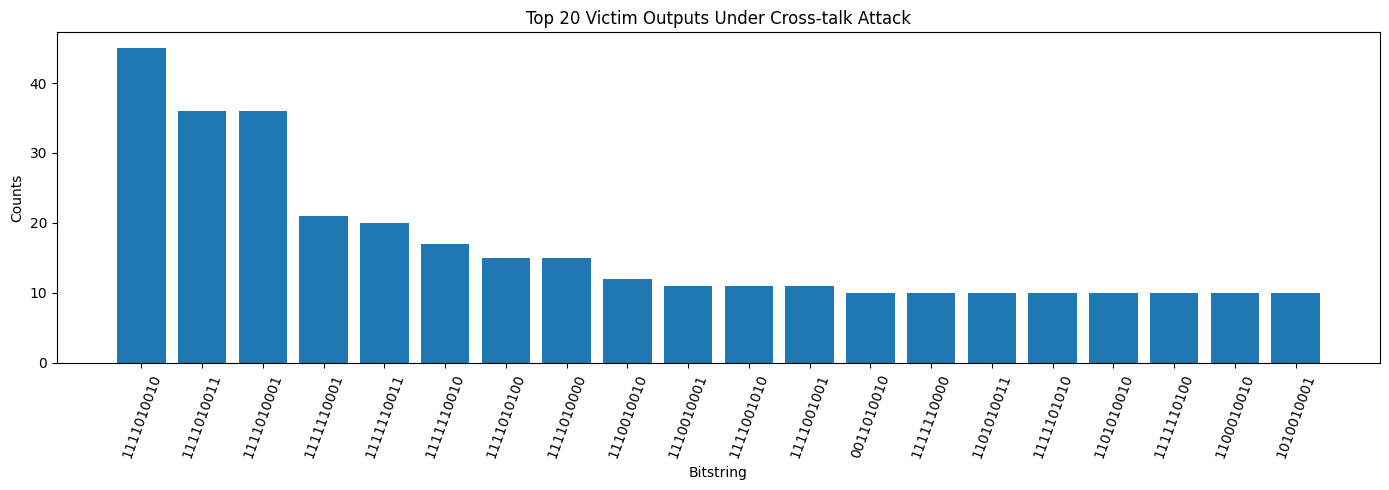

Top-20 output distribution after cross-talk attack visualized successfully!


In [2]:
from collections import Counter
import matplotlib.pyplot as plt

# Show the 20 most frequent output bitstrings after the attack
top_items = Counter(counts).most_common(20)
labels = [x[0] for x in top_items]
values = [x[1] for x in top_items]

plt.figure(figsize=(14,5))
plt.bar(labels, values)
plt.xlabel('Bitstring')
plt.ylabel('Counts')
plt.title('Top 20 Victim Outputs Under Cross-talk Attack')
plt.xticks(rotation=70)
plt.tight_layout()
plt.show()
print("Top-20 output distribution after cross-talk attack visualized successfully!")


In [3]:
from collections import Counter

# Assume baseline_counts is from your initial simulation WITHOUT attackers
baseline_top = Counter(baseline_counts).most_common(10)
attack_top = Counter(counts).most_common(10)

print("Baseline Top 10:")
for k, v in baseline_top:
    print(f"{k}: {v}")
print("\nAttack Top 10:")
for k, v in attack_top:
    print(f"{k}: {v}")

print("Victim output Top 10 comparison before and after attack completed. Ready for report.")



NameError: name 'baseline_counts' is not defined

In [ ]:
from collections import Counter

N = 10  
top_baseline = [x[0] for x in Counter(baseline_counts).most_common(N)]
top_attack = [x[0] for x in Counter(counts).most_common(N)]
all_bitstrings = list(dict.fromkeys(top_baseline + top_attack))

baseline_total = sum(baseline_counts.values())
attack_total = sum(counts.values())

print(f"{'Bitstring':>12} | {'Baseline Prob':>15} | {'Attack Prob':>15}")
print('-'*44)
for bit in all_bitstrings:
    prob_base = baseline_counts.get(bit, 0) / baseline_total
    prob_attack = counts.get(bit, 0) / attack_total
    print(f"{bit:>12} | {prob_base:15.5f} | {prob_attack:15.5f}")

print("Probability comparison for top bitstrings (before and after attack) complete!")


In [ ]:
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np

N = 10  

top_baseline = [x[0] for x in Counter(baseline_counts).most_common(N)]
top_attack = [x[0] for x in Counter(counts).most_common(N)]
all_bitstrings = list(dict.fromkeys(top_baseline + top_attack))

baseline_total = sum(baseline_counts.values())
attack_total = sum(counts.values())
baseline_probs = [baseline_counts.get(bit, 0) / baseline_total for bit in all_bitstrings]
attack_probs = [counts.get(bit, 0) / attack_total for bit in all_bitstrings]

x = np.arange(len(all_bitstrings))
width = 0.35

plt.figure(figsize=(15, 6))
plt.bar(x - width/2, baseline_probs, width, label='Baseline (No Attack)')
plt.bar(x + width/2, attack_probs, width, label='After Cross-talk Attack')
plt.xlabel('Bitstring')
plt.ylabel('Probability')
plt.title('Victim Output Probability: Baseline vs. Cross-talk Attack')
plt.xticks(x, all_bitstrings, rotation=70)
plt.legend()
plt.tight_layout()
plt.show()
print("Probability distribution for top bitstrings (before and after attack) visualized!")
